In [ ]:
!pip install pyod
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score,fbeta_score,roc_auc_score,average_precision_score, mean_absolute_error , median_absolute_error
#from sklearn.svm import OneClassSVM
from pyod.models.knn import KNN
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from math import prod

pd.set_option('display.max_columns', None)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 7.7 MB/s eta 0:00:00


## DATA PREP

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/sebastiansossah/TFM/main/data/df.zip', index_col=0)

/tmp/ipython-input-2866093463.py:1: DtypeWarning: Columns (3,4,5,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://raw.githubusercontent.com/sebastiansossah/TFM/main/data/df.zip', index_col=0)


In [3]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.set_index('Timestamp')
df = df.sort_index()

In [4]:
df.shape

(116166, 99)

In [5]:
def create_sliding_windows(df, window_size, stride):
    """
    Crea ventanas deslizantes separando normal vs anomalía
    + metadata para mapeo ventana → evento
    
    Returns:
        windows_train: lista de ventanas normales
        windows_test: lista de ventanas con anomalías
        metadata_train: dict con info de cada ventana train
        metadata_test: dict con info de cada ventana test
    """
    if 'Block_ID' not in df.columns or 'Anomaly_Event' not in df.columns:
        print("Necesitas Block_ID y Anomaly_Event")
        return None, None, None, None
    
    windows_train = []
    windows_test = []
    metadata_train = []
    metadata_test = []
    
    train_idx = 0
    test_idx = 0
    
    for block_id in sorted(df['Block_ID'].unique()):
        block_data = df[df['Block_ID'] == block_id].copy()
        
        for i in range(0, len(block_data) - window_size + 1, stride):
            window = block_data.iloc[i:i+window_size]
            
            meta = {
                'block_id': block_id,
                'start_time': window.index[0],
                'end_time': window.index[-1],
                'start_idx_in_block': i,
                'anomaly_event': int(window['Anomaly_Event'].max()),
                'has_anomaly': bool(window['Anomaly'].any()),
                'n_anomaly_records': int(window['Anomaly'].sum())
            }
            
            if window['Anomaly_Event'].max() > 0:
                meta['window_idx'] = test_idx
                meta['split'] = 'test'
                windows_test.append(window)
                metadata_test.append(meta)
                test_idx += 1
            else:
                meta['window_idx'] = train_idx
                meta['split'] = 'train'
                windows_train.append(window)
                metadata_train.append(meta)
                train_idx += 1
    

    return windows_train, windows_test, metadata_train, metadata_test

In [6]:
def prepare_data_model_with_pca(
        windows_train, 
        windows_test, 
        pca_components=None
    ):
    """
    Prepara datos con normalización diferenciada para sensores/actuadores
    y añade PCA opcional sobre las ventanas flatten.
    """
    continuous_features = [
        'FIT101', 'LIT101',
        'AIT201', 'AIT202', 'AIT203', 'FIT201',
        'AIT301', 'AIT302', 'AIT303', 'DPIT301', 'FIT301', 'LIT301',
        'AIT401', 'AIT402', 'FIT401', 'LIT401',
        'AIT501', 'AIT502', 'AIT503', 'AIT504',
        'FIT501', 'FIT502', 'FIT503', 'FIT504',
        'PIT501', 'PIT502', 'PIT503',
        'FIT601', 'FIT602', 'LIT601', 'LIT602'
    ]
    
    binary_features = [
        'MV101', 'P101', 'P102',
        'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206',
        'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302',
        'P401', 'P402', 'P403', 'P404', 'UV401',
        'MV501', 'MV502', 'MV503', 'MV504', 'P501', 'P502',
        'P601', 'P602', 'P603'
    ]
    
    all_features = continuous_features + binary_features

    X_train = np.array([w[all_features].values for w in windows_train])
    X_test = np.array([w[all_features].values for w in windows_test])
    
    n_cont = len(continuous_features)

    X_train_cont = X_train[:, :, :n_cont]
    X_train_bin  = X_train[:, :, n_cont:]
    X_test_cont  = X_test[:, :, :n_cont]
    X_test_bin   = X_test[:, :, n_cont:]
    
    scaler = StandardScaler()
    
    n_train, window_size, _ = X_train_cont.shape
    
    X_train_cont_rs = X_train_cont.reshape(-1, n_cont)
    X_test_cont_rs  = X_test_cont.reshape(-1, n_cont)
    
    X_train_cont_scaled = scaler.fit_transform(X_train_cont_rs)
    X_test_cont_scaled  = scaler.transform(X_test_cont_rs)
    
    X_train_cont = X_train_cont_scaled.reshape(n_train, window_size, n_cont)
    X_test_cont  = X_test_cont_scaled.reshape(X_test_cont.shape[0], window_size, n_cont)
    
    X_train_final = np.concatenate([X_train_cont, X_train_bin], axis=2)
    X_test_final  = np.concatenate([X_test_cont, X_test_bin], axis=2)

    if pca_components is not None:
        print("\nAplicando PCA...")

        n_features_total = X_train_final.shape[2]
        
        X_train_flat = X_train_final.reshape(X_train_final.shape[0], window_size * n_features_total)
        X_test_flat  = X_test_final.reshape(X_test_final.shape[0], window_size * n_features_total)

        # PCA
        pca = PCA(n_components=pca_components)
        X_train_pca = pca.fit_transform(X_train_flat)
        X_test_pca  = pca.transform(X_test_flat)

        print("Dimensión original:", window_size * n_features_total)
        print("Dimensión PCA:", X_train_pca.shape[1])
        print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

        return X_train_pca, X_test_pca, scaler, pca, all_features
    
    X_train_flat = X_train_final.reshape(X_train_final.shape[0], -1)
    X_test_flat  = X_test_final.reshape(X_test_final.shape[0],  -1)

    return X_train_flat, X_test_flat, scaler, all_features


In [7]:
EXPERIMENT_CONFIG = {
    'strides': [5,15,30],
    'window_size': [60],
    "n_neighbors": [5,10,15,20,25,30],
    "method": ["largest", "mean", "median"],  
    "contamination": [0.005, 0.01, 0.02]}

In [ ]:


count = prod(len(EXPERIMENT_CONFIG[key]) for key in ['strides', 'n_neighbors', 'method', 'contamination'])
print(count)

162


In [9]:
def get_scores(model, X_train, X_test):

    model.fit(X_train)
    
    # --- Correct Threshold ---
    # PyOD models calculate the optimal threshold based on the 'contamination' parameter
    # and the decision scores of the training data (model.decision_scores_).
    # Use the pre-calculated threshold_ attribute.
    if hasattr(model, "threshold_"):
        threshold = model.threshold_
        score_direction = "high_is_anomaly" # PyOD default
        train_scores = model.decision_scores_
        test_scores = model.decision_function(X_test)
    else:
        # Fallback for sklearn models like OneClassSVM
        # which don't have a contamination-based threshold_
        # and require a different approach (e.g., threshold=0 in OCSVM)
        # or manual threshold setting. Sticking to 0 for simplicity here 
        # as it was the original design for a potential OCSVM path.
        threshold = 0
        score_direction = "low_is_anomaly" # OCSVM default
        train_scores = model.decision_function(X_train)
        test_scores = model.decision_function(X_test)


    # --- y_true ---
    # True positives (anomalies) are ONLY in the test set.
    y_true = np.concatenate([
        np.zeros(len(train_scores)),
        np.ones(len(test_scores))
    ])

    # --- y_pred (using the correct threshold) ---
    if score_direction == "high_is_anomaly":
        y_pred = np.concatenate([
            (train_scores > threshold).astype(int),
            (test_scores > threshold).astype(int)
        ])
    else:
        y_pred = np.concatenate([
            (train_scores < threshold).astype(int),
            (test_scores < threshold).astype(int)
        ])

    # --- metrics ---
    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    mae = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    
    # Check how many test windows were predicted normal (sanity check)
    # This is the proportion of False Negatives / Total Test Samples
    pru = np.mean(y_pred[len(train_scores):] == 0)

    # Return the threshold as well for logging/inspection
    return f1, precision, recall, mae, medae, pru, threshold

In [ ]:

log_result_params = []

for stride in EXPERIMENT_CONFIG['strides']:
    windows_train, windows_test, metadata_train, metadata_test = create_sliding_windows(
                    df, 
                    window_size=60, 
                    stride=stride)

    X_train, X_test, scaler, pca, all_features = prepare_data_model_with_pca(
        windows_train, 
        windows_test, 
        pca_components=10)

    for  n_neighbors, method, contamination in product(
                EXPERIMENT_CONFIG['n_neighbors'], 
                EXPERIMENT_CONFIG['method'], 
                EXPERIMENT_CONFIG['contamination']):

        knn = KNN(
        n_neighbors=n_neighbors,
        method=method,
        contamination=contamination,
        n_jobs=-1)

        f1, precision, recall, mae, medae, pru, threshold = get_scores(knn, X_train, X_test) 

        log_result_params.append(
            {'strides':stride,
                'window':60,
                'n_neighbors':n_neighbors,
                'method':method,
                'contamination':contamination,
                'precision':precision, 'recall':recall,'mae':mae, 'medae':medae,'pru':pru ,'f1': f1})

        


Aplicando PCA...
Dimensión original: 3660
Dimensión PCA: 10
Varianza explicada acumulada: 0.8618053986044795

Aplicando PCA...
Dimensión original: 3660
Dimensión PCA: 10
Varianza explicada acumulada: 0.861846725820776

Aplicando PCA...
Dimensión original: 3660
Dimensión PCA: 10
Varianza explicada acumulada: 0.8617056051809606


In [23]:
len(log_result_params)

162

In [12]:
df_resultados = pd.DataFrame(log_result_params)

In [13]:
df_resultados.sort_values(by='f1', ascending=False)

,strides,window,n_neighbors,method,contamination,precision,recall,mae,medae,pru,f1
5,5,60,5,mean,0.020,0.959294,0.813693,0.081059,0.0,0.186307,0.880515
8,5,60,5,median,0.020,0.958089,0.789300,0.090013,0.0,0.210700,0.865542
4,5,60,5,mean,0.010,0.977643,0.757483,0.095376,0.0,0.242517,0.853595
7,5,60,5,median,0.010,0.977259,0.744403,0.100177,0.0,0.255597,0.845084
14,5,60,10,mean,0.020,0.955397,0.739571,0.108266,0.0,0.260429,0.833743
...,...,...,...,...,...,...,...,...,...,...,...
126,30,60,15,largest,0.005,0.745098,0.026798,0.361068,0.0,0.973202,0.051736
99,15,60,30,largest,0.005,0.750000,0.026427,0.361608,0.0,0.973573,0.051055
135,30,60,20,largest,0.005,0.734694,0.025388,0.361586,0.0,0.974612,0.049080
144,30,60,25,largest,0.005,0.593750,0.013399,0.365993,0.0,0.986601,0.026207


In [34]:

windows_train, windows_test, metadata_train, metadata_test = create_sliding_windows(
                    df, 
                    window_size=60, 
                    stride=30)

X_train, X_test, scaler, pca, all_features = prepare_data_model_with_pca(
        windows_train, 
        windows_test, 
        pca_components=10)



knn = KNN(
        n_neighbors=5,
        method="mean",
        contamination=0.020,
        n_jobs=-1)

f1, precision, recall, mae, medae, pru, threshold = get_scores(knn, X_train, X_test) 



Aplicando PCA...
Dimensión original: 3660
Dimensión PCA: 10
Varianza explicada acumulada: 0.8617056051795732


In [21]:
best_by_pca = df_resultados.loc[df_resultados.groupby(["strides"])["f1"].idxmax()]

In [22]:
best_by_pca

,strides,window,n_neighbors,method,contamination,precision,recall,mae,medae,pru,f1
5,5,60,5,mean,0.02,0.959294,0.813693,0.081059,0.0,0.186307,0.880515
59,15,60,5,mean,0.02,0.941388,0.554616,0.176654,0.0,0.445384,0.698004
113,30,60,5,mean,0.02,0.925191,0.427362,0.223173,0.0,0.572638,0.584660


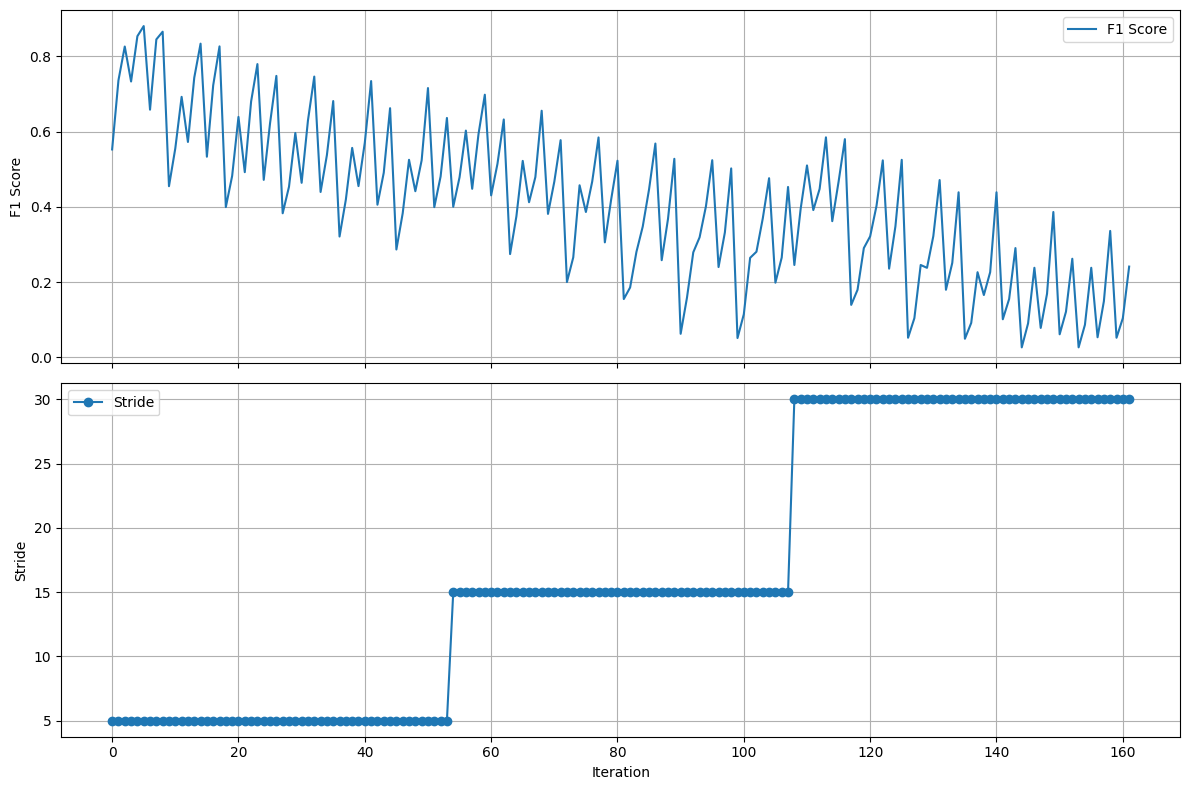

In [28]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- F1 plot ---
ax[0].plot(results_df['iteration'], results_df['f1'], label='F1 Score')
ax[0].set_ylabel("F1 Score")
ax[0].grid(True)
ax[0].legend()

# --- Stride plot ---
ax[1].plot(results_df['iteration'], results_df['strides'], label='Stride', linestyle='-', marker='o')
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Stride")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()
